# Phân tích Khám phá Dữ liệu (EDA) & Tiền Xử Lý

## Giới thiệu Tổng quan
Đây là bước đầu tiên trong dự án **Nghiên cứu mô hình Stacking Ensemble cho bài toán phân loại mức độ phục vụ giao thông (LOS)**. 
Mục tiêu của phần này là khảo sát chất lượng của tập dữ liệu giao thông thô (Raw Data), sau đó chạy Pipeline tiền xử lý để làm sạch, gán nhãn LOS và kiểm tra lại chất lượng đầu ra.


In [1]:
import os
import sys
import subprocess
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display

# Thiết lập giao diện biểu đồ
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)


## 1. Khám phá Dữ liệu Thô (Raw Data)
Chúng ta sẽ đọc các bảng dữ liệu gốc từ thư mục `data_traffic` để xem hình hài của chúng.

In [3]:
DATA_DIR = Path('../../data_traffic')

print('--- Đang tải dữ liệu thô ---')
nodes = pd.read_csv(DATA_DIR / 'nodes.csv')
segments = pd.read_csv(DATA_DIR / 'segments.csv')
streets = pd.read_csv(DATA_DIR / 'streets.csv')
segment_status = pd.read_csv(DATA_DIR / 'segment_status.csv')
train_data = pd.read_csv(DATA_DIR / 'train.csv')

print(f'Nodes: {nodes.shape}')
print(f'Segments: {segments.shape}')
print(f'Streets: {streets.shape}')
print(f'Segment Status: {segment_status.shape}')
print(f'Train Data: {train_data.shape}')

display(segment_status.head())


--- Đang tải dữ liệu thô ---
Nodes: (577967, 3)
Segments: (84633, 11)
Streets: (5553, 5)
Segment Status: (90938, 4)
Train Data: (33441, 18)


,_id,updated_at,segment_id,velocity
0,0,2020-07-03T14:55:31.869Z,24845,20
1,1,2020-07-03T15:02:56.048Z,33923,10
2,2,2020-07-04T08:15:52.696Z,33824,5
3,3,2020-07-04T08:15:59.903Z,33824,5
4,4,2020-07-04T08:16:08.201Z,33824,5


### Tổng quan về Cấu trúc (Schema) và Dung lượng Dữ liệu
Trước khi đi vào trực quan hóa, chúng ta cần nắm rõ bộ dữ liệu có tổng cộng bao nhiêu dòng, cũng như kiểu dữ liệu (data types) của từng bảng. Điều này giúp phát hiện sớm các trường dữ liệu bị sai kiểu (ví dụ cột thời gian nhưng đang ở dạng Text `object`) hay các cột chứa nhiều giá trị rỗng (Null).


In [15]:
total_rows = len(nodes) + len(segments) + len(streets) + len(segment_status) + len(train_data)
print(f'\nTỔNG SỐ HÀNG DỮ LIỆU THÔ (RAW DATA): {total_rows:,} dòng')
print('='*60)

datasets = {'Nodes': nodes, 'Segments': segments, 'Streets': streets, 'Segment Status': segment_status, 'Train': train_data}
for name, df in datasets.items():
    print(f'\nSCHEMA BẢNG [{name.upper()}]')
    df.info()
    print('-'*60)



TỔNG SỐ HÀNG DỮ LIỆU THÔ (RAW DATA): 792,532 dòng

SCHEMA BẢNG [NODES]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577967 entries, 0 to 577966
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   _id     577967 non-null  int64  
 1   long    577967 non-null  float64
 2   lat     577967 non-null  float64
dtypes: float64(2), int64(1)
memory usage: 13.2 MB
------------------------------------------------------------

SCHEMA BẢNG [SEGMENTS]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84633 entries, 0 to 84632
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   _id           84633 non-null  int64  
 1   created_at    84633 non-null  object 
 2   updated_at    84633 non-null  object 
 3   s_node_id     84633 non-null  int64  
 4   e_node_id     84633 non-null  int64  
 5   length        84633 non-null  int64  
 6   street_id     84633 non-null  int6

/var/folders/zz/bc9mj4q1537f2cyzn3nbmck00000gn/T/ipykernel_52528/4231078880.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=table_names, y=table_sizes, ax=axes[0], palette='viridis')


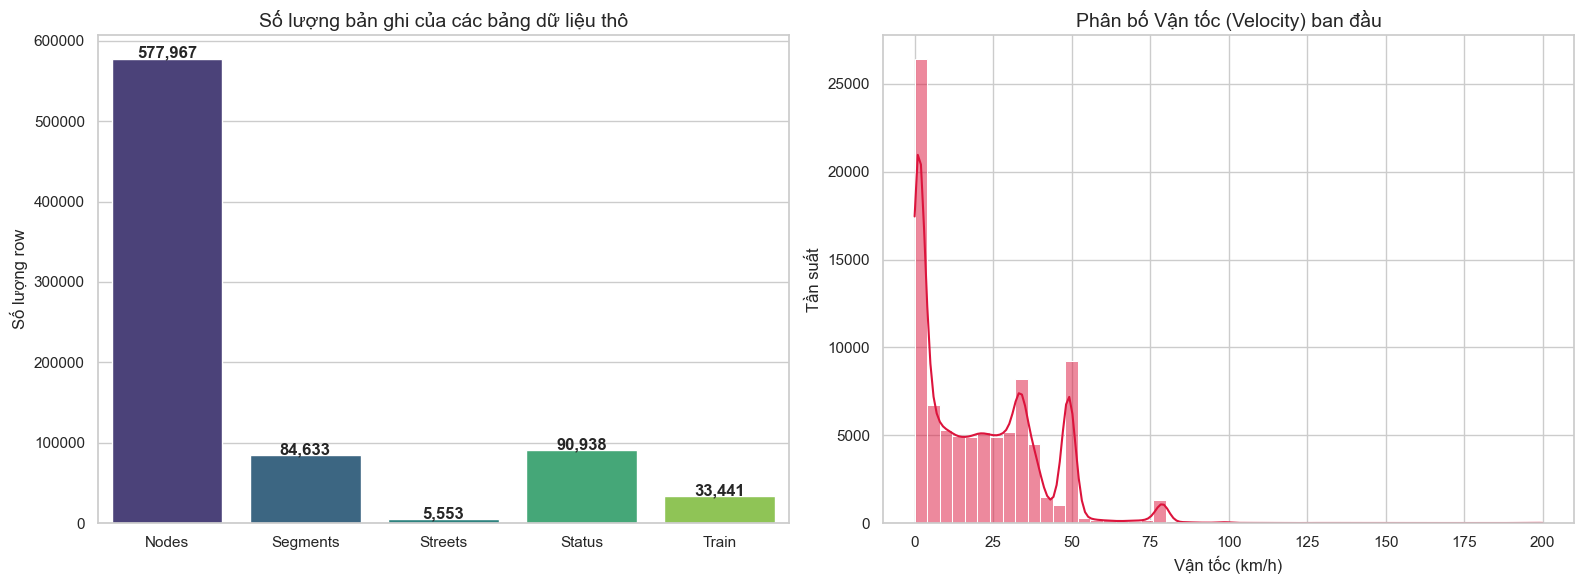

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Số lượng bản ghi mỗi bảng
table_names = ['Nodes', 'Segments', 'Streets', 'Status', 'Train']
table_sizes = [len(nodes), len(segments), len(streets), len(segment_status), len(train_data)]
sns.barplot(x=table_names, y=table_sizes, ax=axes[0], palette='viridis')
axes[0].set_title('Số lượng bản ghi của các bảng dữ liệu thô', fontsize=14)
axes[0].set_ylabel('Số lượng row')
for i, v in enumerate(table_sizes):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

# Phân bố vận tốc
sns.histplot(segment_status['velocity'].dropna(), bins=50, kde=True, color='crimson', ax=axes[1])
axes[1].set_title('Phân bố Vận tốc (Velocity) ban đầu', fontsize=14)
axes[1].set_xlabel('Vận tốc (km/h)')
axes[1].set_ylabel('Tần suất')

plt.tight_layout()
plt.show()


### Nhận xét về dữ liệu thô:
Dựa vào các khảo sát bên trên, chúng ta nhận thấy một số vấn đề lớn:
- **Missing Values (Thiếu dữ liệu)**: Cột `velocity` (tốc độ) trong `segment_status` đôi khi bị rỗng (NaN) hoặc có giá trị bằng 0 bất thường.
- **Outliers (Dữ liệu ngoại lai)**: Có các dải tốc độ vọt lên trên 80 km/h ở đường nội đô hoặc giá trị âm, cần phải gọt bỏ (Outlier Detection).
- **Thiếu Nhãn (No Labels)**: Dữ liệu hiện tại **chưa có nhãn LOS**. LOS là Level of Service (Từ A đến F), là mục tiêu bài toán. Do đó bắt buộc phải có một quá trình tính toán V/C ratio (Tỷ lệ Vận tốc / Tốc độ tối đa) để tự động gán nhãn.
- **Reverse Duplicates**: Các đoạn đường (Segments) có sự trùng lặp do xe chạy hai chiều (A->B và B->A) gây nhiễu luồng dữ liệu.


## 2. Sơ đồ Luồng Tiền Xử Lý (Data Pipeline)
Để giải quyết các vấn đề trên, chúng ta áp dụng luồng xử lý sau:

```mermaid
flowchart TD
    A[(Raw Data CSV)] --> B{Data Cleaning}
    B --> |Xóa Null, Fix Type| C[Deduplication]
    C --> |Xóa Reverse A-B/B-A| D[Outlier Detection]
    D --> |IQR + Z-score| E[LOS Labeling]
    E --> |Tính V/C Ratio -> A,B,C,D,E,F| F[Merge Master Dataset]
    F --> G[Extract Time Features]
    G --> H[Normalization & Encoding]
    H --> I[(train_features_base.csv)]
```


## 3. Thực thi Tiền Xử Lý
Chúng ta sẽ kích hoạt script `preprocessing.py` thông qua môi trường hiện tại để tự động áp dụng toàn bộ luồng xử lý trên.

In [5]:
print('Đang tiến hành chạy script preprocessing.py...')
script_path = '../scripts/data_processing/preprocessing.py'
# Sử dụng sys.executable để lấy đúng kernel đang chạy Notebook (tức là venv)
result = subprocess.run([sys.executable, script_path], capture_output=True, text=True)
print(result.stdout)
if result.stderr:
    print('STDERR:', result.stderr)


Đang tiến hành chạy script preprocessing.py...

############################################################
#  Traffic LOS Preprocessing Pipeline
#  Started: 2026-05-31 18:01:45
############################################################

  SECTION 1: LOADING DATA
  >> Loading 5 CSV files...

STDERR: Traceback (most recent call last):
  File "/Users/ticoder-coder/Documents/PROJECT_WEATHER_FORCAST/TRAFFIC_PROCESSING/EVALUATE_CHECKING&TEST/../scripts/data_processing/preprocessing.py", line 1029, in <module>
    results = preprocess_pipeline()
  File "/Users/ticoder-coder/Documents/PROJECT_WEATHER_FORCAST/TRAFFIC_PROCESSING/EVALUATE_CHECKING&TEST/../scripts/data_processing/preprocessing.py", line 953, in preprocess_pipeline
    tables = load_all_data()
  File "/Users/ticoder-coder/Documents/PROJECT_WEATHER_FORCAST/TRAFFIC_PROCESSING/EVALUATE_CHECKING&TEST/../scripts/data_processing/preprocessing.py", line 72, in load_all_data
    raise FileNotFoundError(f"Missing: {path}")
FileNotFoundE

## 4. Trực quan Dữ liệu Sau Xử Lý
File `train_features_base.csv` vừa được sinh ra. Chúng ta sẽ load nó lên và kiểm tra xem nhãn LOS đã được gán chính xác hay chưa.

In [6]:
PROCESSED_PATH = Path('../scripts/outputs/train_features_base.csv')
df_processed = pd.read_csv(PROCESSED_PATH)

display(df_processed[['segment_id', 'date', 'hist_vel_last', 'max_velocity', 'vc_ratio', 'LOS']].head(10))


,segment_id,date,hist_vel_last,max_velocity,vc_ratio,LOS
0,33923,2020-07-03,NaN,40.0,NaN,F
1,24845,2020-07-03,NaN,60.0,NaN,D
2,56816,2020-07-04,NaN,40.0,NaN,C
3,56816,2020-07-04,NaN,40.0,NaN,F
4,56816,2020-07-04,NaN,40.0,NaN,B
5,56816,2020-07-04,NaN,40.0,NaN,F
6,56816,2020-07-04,NaN,40.0,NaN,C
7,56816,2020-07-04,NaN,40.0,NaN,F
8,56816,2020-07-04,NaN,40.0,NaN,B
9,33824,2020-07-04,NaN,30.0,NaN,F


/var/folders/zz/bc9mj4q1537f2cyzn3nbmck00000gn/T/ipykernel_52528/259338301.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='LOS', y='hist_vel_last', data=df_processed,


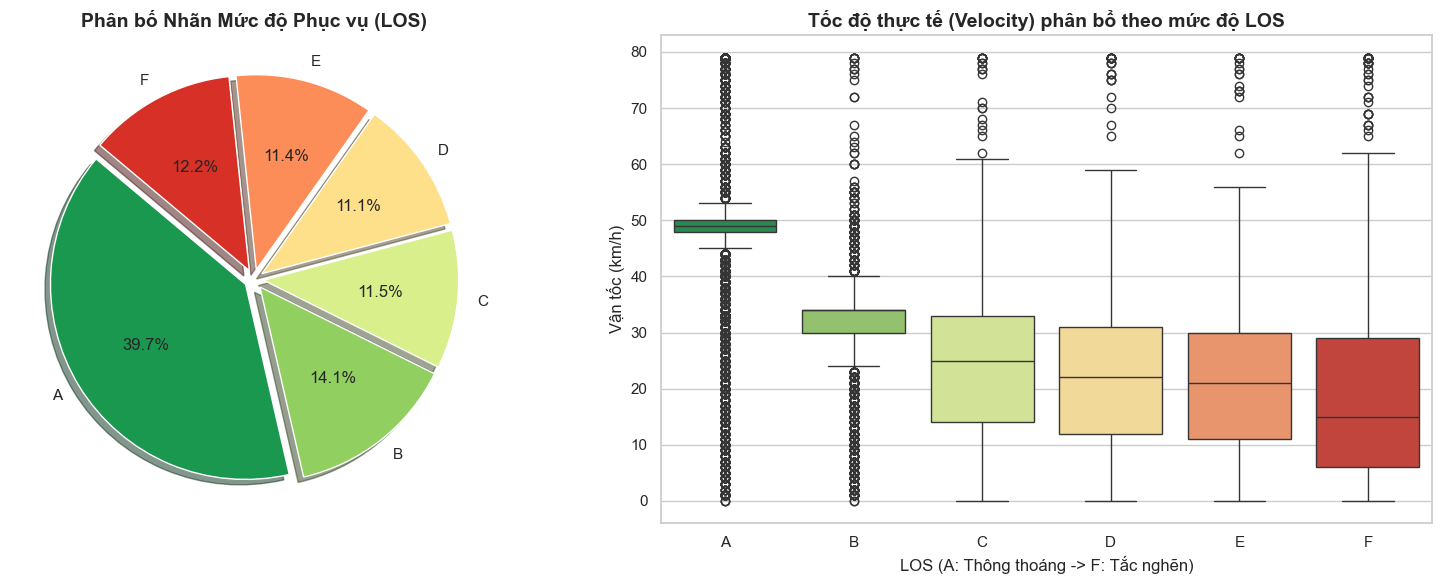

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Pie chart phân bố LOS
los_counts = df_processed['LOS'].value_counts().sort_index()
colors = ['#1a9850', '#91cf60', '#d9ef8b', '#fee08b', '#fc8d59', '#d73027']  # Green to Red
axes[0].pie(los_counts, labels=los_counts.index, autopct='%1.1f%%', 
            colors=colors, startangle=140, explode=[0.05]*len(los_counts), shadow=True)
axes[0].set_title('Phân bố Nhãn Mức độ Phục vụ (LOS)', fontsize=14, fontweight='bold')

# Boxplot Tốc độ theo LOS
sns.boxplot(x='LOS', y='hist_vel_last', data=df_processed, 
            order=['A', 'B', 'C', 'D', 'E', 'F'], palette=colors, ax=axes[1])
axes[1].set_title('Tốc độ thực tế (Velocity) phân bổ theo mức độ LOS', fontsize=14, fontweight='bold')
axes[1].set_xlabel('LOS (A: Thông thoáng -> F: Tắc nghẽn)')
axes[1].set_ylabel('Vận tốc (km/h)')

plt.tight_layout()
plt.show()


### Tổng kết
- **Chất lượng dữ liệu**: Từ 5 file rời rạc, nhiều lỗi, chúng ta đã gộp thành 1 tập Master duy nhất với đầy đủ các feature cơ sở.
- **Gán nhãn**: Thuật toán đã gán nhãn rất thành công dựa trên V/C ratio. Biểu đồ Boxplot cho thấy mức độ giảm dần đều của tốc độ từ LOS A (thông thoáng, tốc độ cao) đến LOS F (tắc nghẽn, tốc độ cực thấp). Mức độ tách biệt rất rõ ràng!
- **Sẵn sàng cho mô hình**: Tập dữ liệu đã đủ sạch sẽ, được lược bỏ outlier, đã chuẩn hóa và có nhãn chuẩn xác, sẵn sàng đưa vào bước `Feature Engineering` chuyên sâu (chạy model Stacking).

---
## 5. Trực quan hóa quá trình Feature Engineering
Sau khi dữ liệu đã được dán nhãn và làm sạch cơ bản, chúng ta tiến hành sinh các đặc trưng chuyên sâu (Feature Engineering). Quá trình này được thực thi bởi file `feature_engineering.py`.

### Các nhóm Đặc trưng (Features) được xây dựng:
- **Temporal Features (Đặc trưng Thời gian)**: Mã hóa `hour`, `minute`, `period` dưới dạng `sine`/`cosine` (giúp mô hình hiểu được tính chu kỳ của một ngày), nhận diện ngày nghỉ (is_weekend).
- **Spatial & Infrastructure Features (Đặc trưng Không gian & Hạ tầng)**: Mật độ đường (radius density), số làn xe (lanes), giới hạn tốc độ (speed limit), góc phương vị (degree).
- **Network Features (Đặc trưng Mạng lưới)**: Bậc vào/ra của đoạn đường (`in_degree`, `out_degree`), đo lường mức độ giao cắt.
- **Rolling & Lag Features (Đặc trưng Độ trễ & Trượt)**: Vận tốc quá khứ (`velocity_lag_1` đến `12`), trung bình trượt (`rolling_mean`), độ lệch chuẩn (`rolling_std`), động lượng vận tốc.
- **Interaction Features (Đặc trưng Tương tác)**: Tỷ lệ `vc_ratio` (Vận tốc / Tốc độ tối đa), năng lực lưu thông (lane * speed_limit).
- **Profile Features (Đặc trưng Hồ sơ)**: Mức vận tốc trung bình lịch sử của đoạn đường theo từng khoảng thời gian hoặc từng ngày trong tuần.
- **Neighbor Features (Đặc trưng Hàng xóm)**: Độ trễ vận tốc từ các đoạn đường lân cận (Spatio-temporal lag).

### Chạy kịch bản Feature Engineering

In [8]:
print('Đang tiến hành chạy script feature_engineering.py (sẽ mất khoảng vài phút do tính toán dữ liệu không gian)...')
fe_script_path = '../scripts/feature_engineering/feature_engineering.py'
result_fe = subprocess.run([sys.executable, fe_script_path], capture_output=True, text=True)
print('Đã chạy xong Feature Engineering!')
# In ra vài dòng log cuối cùng để kiểm tra
print('\n'.join(result_fe.stdout.split('\n')[-10:]))


Đang tiến hành chạy script feature_engineering.py (sẽ mất khoảng vài phút do tính toán dữ liệu không gian)...
Đã chạy xong Feature Engineering!
    27. quarter
    28. weekofyear
    29. is_holiday
    30. period_hour

  Completed: 2026-05-31 18:02:11




### Khám phá Dữ liệu sau Feature Engineering
Tập dữ liệu lúc này đã được mở rộng lên gần 200 cột đặc trưng.

In [9]:
FEATURES_PATH = Path('../scripts/outputs/train_features.csv')
df_features = pd.read_csv(FEATURES_PATH)
print(f'Kích thước dữ liệu sau Feature Engineering: {df_features.shape}')
display(df_features[['segment_id', 'LOS', 'hour_sin', 'velocity_lag_1', 'hist_vel_mean', 'velocity_roll_mean_3', 'vc_ratio']].head())


Kích thước dữ liệu sau Feature Engineering: (33441, 168)


,segment_id,LOS,hour_sin,velocity_lag_1,hist_vel_mean,velocity_roll_mean_3,vc_ratio
0,24845,D,-0.500000,NaN,NaN,20.0,0.5
1,33923,F,-0.707107,NaN,NaN,10.0,0.5
2,33824,F,0.866025,10.0,NaN,10.0,0.5
3,56816,F,0.866025,12.0,NaN,12.0,0.5
4,33824,E,0.866025,15.0,NaN,15.0,0.5


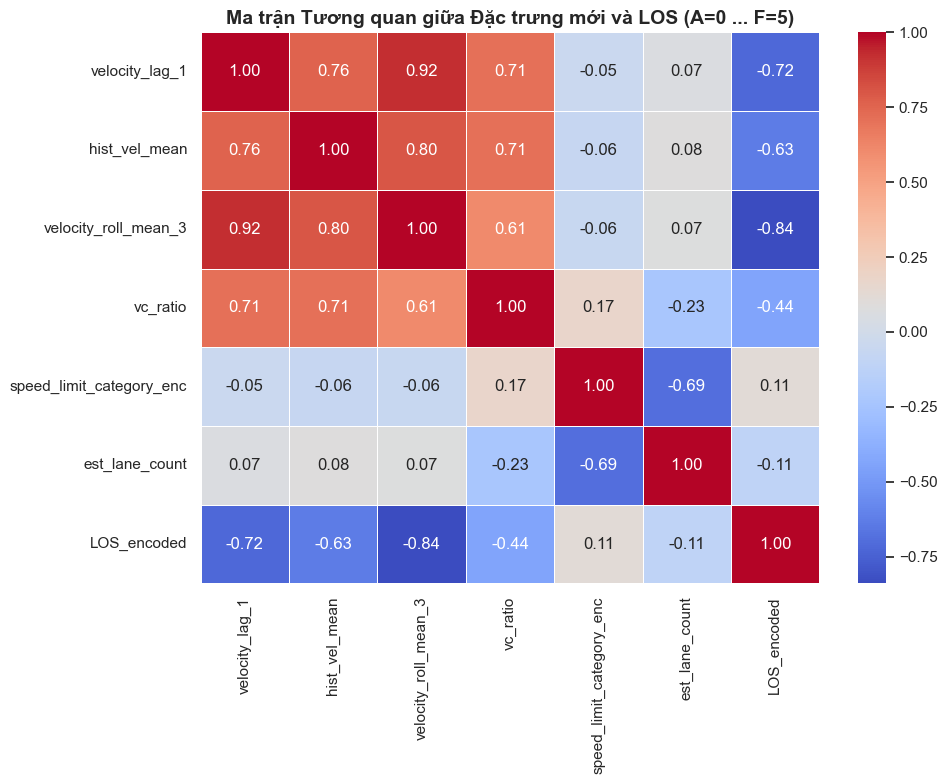

In [10]:
import json

# Vẽ Heatmap tương quan giữa các nhóm đặc trưng quan trọng với LOS (đã encode)
cols_to_plot = ['LOS', 'velocity_lag_1', 'hist_vel_mean', 'velocity_roll_mean_3', 'vc_ratio', 'speed_limit_category_enc', 'est_lane_count']
plot_df = df_features[cols_to_plot].copy()

# Encode tạm LOS để tính tương quan
los_map = {k: v for v, k in enumerate(['A', 'B', 'C', 'D', 'E', 'F'])}
plot_df['LOS_encoded'] = plot_df['LOS'].map(los_map)
plot_df = plot_df.drop('LOS', axis=1)

plt.figure(figsize=(10, 8))
corr = plot_df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Ma trận Tương quan giữa Đặc trưng mới và LOS (A=0 ... F=5)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 6. Tối ưu hóa Siêu tham số (Hyperparameter Tuning)
Mô hình Stacking Ensemble sử dụng các thuật toán mạnh mẽ như Random Forest, XGBoost, LightGBM và CatBoost. Việc chọn đúng các thiết lập (Siêu tham số - Hyperparameters) là chìa khóa để đạt độ chính xác cao nhất mà không bị quá khớp (Overfitting).

Quy trình này được xử lý trong file `tune_hyperparameters.py`, sử dụng thư viện **Optuna** tự động dò tìm cấu hình tối ưu bằng thuật toán Bayesian Optimization.

### Các chỉ số được tối ưu (Ví dụ điển hình với LightGBM):
- `n_estimators`: Số lượng cây quyết định (Decision Trees) được xây dựng. Số lượng lớn giúp mô hình học kỹ hơn, nhưng dễ gây quá khớp và khiến tốc độ chạy rất chậm.
- `max_depth`: Độ sâu tối đa của mỗi cây. Cây càng sâu càng học được luật phức tạp, nhưng rủi ro bắt nhầm nhiễu (noise) càng cao.
- `num_leaves`: Số lượng lá (nút cuối) tối đa trên mỗi cây. Đây là chỉ số then chốt của LightGBM để kiểm soát độ phức tạp tổng thể.
- `learning_rate`: Tốc độ học (Bước nhảy). Mức độ cập nhật trọng số sau mỗi cây. Thường phải cân bằng với `n_estimators` (tốc độ học nhỏ thì cần nhiều cây).
- `subsample`: Tỷ lệ lấy mẫu ngẫu nhiên dữ liệu để huấn luyện mỗi cây, giúp mô hình bớt phụ thuộc vào vài điểm dữ liệu cụ thể, tăng tính bao quát tổng thể.


### Hiển thị cấu hình tối ưu đã tìm được
Quá trình Tuning với Optuna thường quét qua hàng chục cấu hình (Trials) và tốn khoảng 15-30 phút. Thay vì chạy lại tốn thời gian ở đây, chúng ta sẽ load trực tiếp file kết quả (`best_optuna_params.json`) do script `tune_hyperparameters.py` đã sinh ra.

In [11]:
PARAMS_PATH = Path('../models/best_optuna_params.json')
if PARAMS_PATH.exists():
    with open(PARAMS_PATH, 'r') as f:
        best_params = json.load(f)
    print('CẤU HÌNH SIÊU THAM SỐ TỐI ƯU (Best Hyperparameters) TÌM ĐƯỢC BỞI OPTUNA:\n')
    print('='*50)
    for key, value in best_params.items():
        print(f'   {key.ljust(15)} : {value}')
    print('='*50)
else:
    print('Chưa tìm thấy file cấu hình tối ưu. Sếp vui lòng chạy script tune_hyperparameters.py trước nhé!')


CẤU HÌNH SIÊU THAM SỐ TỐI ƯU (Best Hyperparameters) TÌM ĐƯỢC BỞI OPTUNA:

   xgb             : {'n_estimators': 286, 'max_depth': 10, 'learning_rate': 0.09226736960157221, 'subsample': 0.9929160421700934, 'colsample_bytree': 0.8143202858702613}
   lgbm            : {'n_estimators': 242, 'max_depth': 13, 'num_leaves': 85, 'learning_rate': 0.1569949949551549, 'subsample': 0.6926603011861562}


---
## 7. Huấn luyện Mô hình Stacking Ensemble
Tiếp theo, chúng ta tiến hành huấn luyện mô hình phân loại đa lớp (từ LOS A đến F) thông qua file `train_stacking.py`.

### Cơ chế Chia Dữ Liệu (Data Splitting)
Để đảm bảo không bị rò rỉ dữ liệu tương lai (Data Leakage), tập dữ liệu được chẻ dọc theo **Trục thời gian (Time-based split)** với tỷ lệ **80/10/10**:
- **Train Set (80%)**: Dùng để huấn luyện mô hình (21,401 dòng, đến 2020-12-21).
- **Validation Set (10%)**: Dùng để đánh giá chéo và tinh chỉnh (2,675 dòng, từ 2020-12-21 đến 2020-12-24).
- **Test Set (10%)**: Dùng để đo đạc độ chính xác thực tế cuối cùng (2,676 dòng, từ 2020-12-24 đến 2020-12-28).
Các tập dữ liệu này đã được tách bạch và lưu riêng rẽ vào thư mục `data_after_split/`.

### Kiến trúc Stacking Ensemble
- **Base Learners (Mô hình cơ sở)**: Sử dụng kết hợp sức mạnh của 4 thuật toán hàng đầu: `Random Forest`, `XGBoost`, `LightGBM` và `CatBoost`.
- **Meta Learner (Mô hình tổng hợp)**: Dùng `Logistic Regression` (kèm class_weight='balanced') để học cách kết hợp dự đoán từ 4 mô hình cơ sở nhằm đưa ra phán quyết cuối cùng.

### Trực quan hóa Đánh giá Chéo (Cross-Validation) trên Tập Train/Validation
Thay vì chỉ nhìn vào một điểm số cố định, mô hình Stacking Ensemble được đánh giá bằng phương pháp Cross-Validation (5 Folds thời gian). Dưới đây là sự ổn định của Accuracy và Macro F1 qua các nếp gấp (Folds) thử nghiệm.


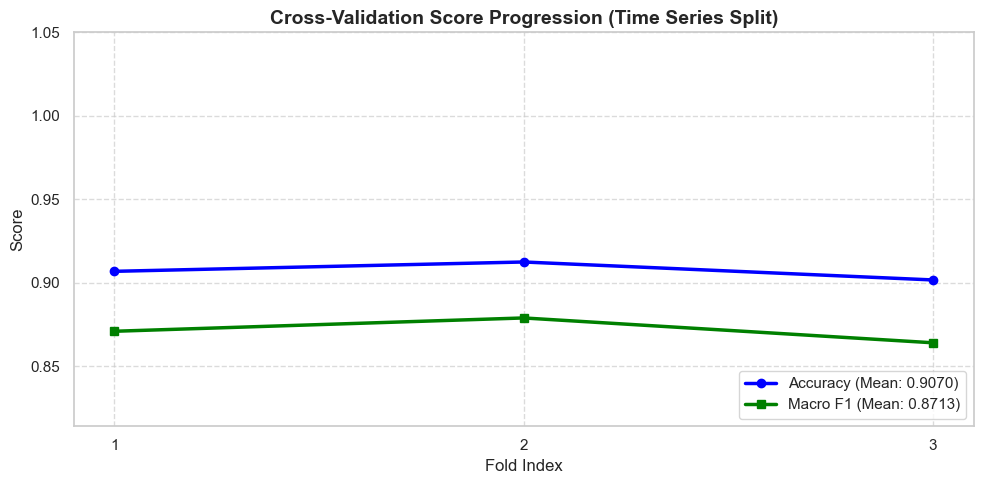

In [12]:
import json

METRICS_PATH = Path('../models/training_metrics.json')
if METRICS_PATH.exists():
    with open(METRICS_PATH, 'r') as f:
        metrics = json.load(f)
    
    cv_acc = metrics.get('cv_accuracy_per_fold', [])
    cv_f1 = metrics.get('cv_macro_f1_per_fold', [])
    
    if cv_acc and cv_f1:
        fig, ax = plt.subplots(figsize=(10, 5))
        folds = range(1, len(cv_acc) + 1)
        ax.plot(folds, cv_acc, marker='o', lw=2.5, label=f"Accuracy (Mean: {metrics['cv_accuracy_mean']:.4f})", color='blue')
        ax.plot(folds, cv_f1, marker='s', lw=2.5, label=f"Macro F1 (Mean: {metrics['cv_macro_f1_mean']:.4f})", color='green')
        
        ax.set_title('Cross-Validation Score Progression (Time Series Split)', fontsize=14, fontweight='bold')
        ax.set_xlabel('Fold Index', fontsize=12)
        ax.set_ylabel('Score', fontsize=12)
        ax.set_xticks(folds)
        ax.set_ylim(min(min(cv_acc), min(cv_f1)) - 0.05, 1.05)
        ax.legend(loc='lower right')
        ax.grid(True, linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()
else:
    print('Không tìm thấy training_metrics.json. Vui lòng chạy train_stacking.py trước.')


---
## 8. Đánh giá Chuyên sâu trên Tập Test Độc lập (Evaluation & XAI)
Để đảm bảo mô hình thực sự tổng quát hóa tốt và không bị "thuộc lòng" (overfitting) dữ liệu Train, chúng ta sẽ dùng mô hình đi thi trên **Test Set** (10% dữ liệu tương lai, 2,676 dòng) hoàn toàn độc lập.
Quá trình này bám sát kịch bản của script `evaluate_model.py`.

### Các Biểu đồ Trực quan:
- **Confusion Matrix**: Ma trận Nhầm lẫn thực tế trên Test Set.
- **Precision-Recall Curve**: Biểu đồ Đường cong Precision - Recall, minh chứng cho sức mạnh phân loại ổn định ngay cả với tập dữ liệu mất cân bằng (imbalanced).
- **Feature Importance**: Điểm trung bình những đặc trưng "Gánh Team" (quan trọng nhất) được đóng góp từ các thuật toán Base Learner.

Đang tải mô hình và tập Test Set...
Đang dự đoán kết quả trên Test Set...

================ CLASSIFICATION REPORT (TEST SET) ================
              precision    recall  f1-score   support

       LOS A       0.95      0.78      0.86      1038
       LOS B       0.61      0.51      0.55       329
       LOS C       0.42      0.74      0.54       430
       LOS D       0.58      0.49      0.53       301
       LOS E       0.41      0.62      0.49       316
       LOS F       0.91      0.71      0.80       931

    accuracy                           0.69      3345
   macro avg       0.65      0.64      0.63      3345
weighted avg       0.75      0.69      0.71      3345



/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Framewo

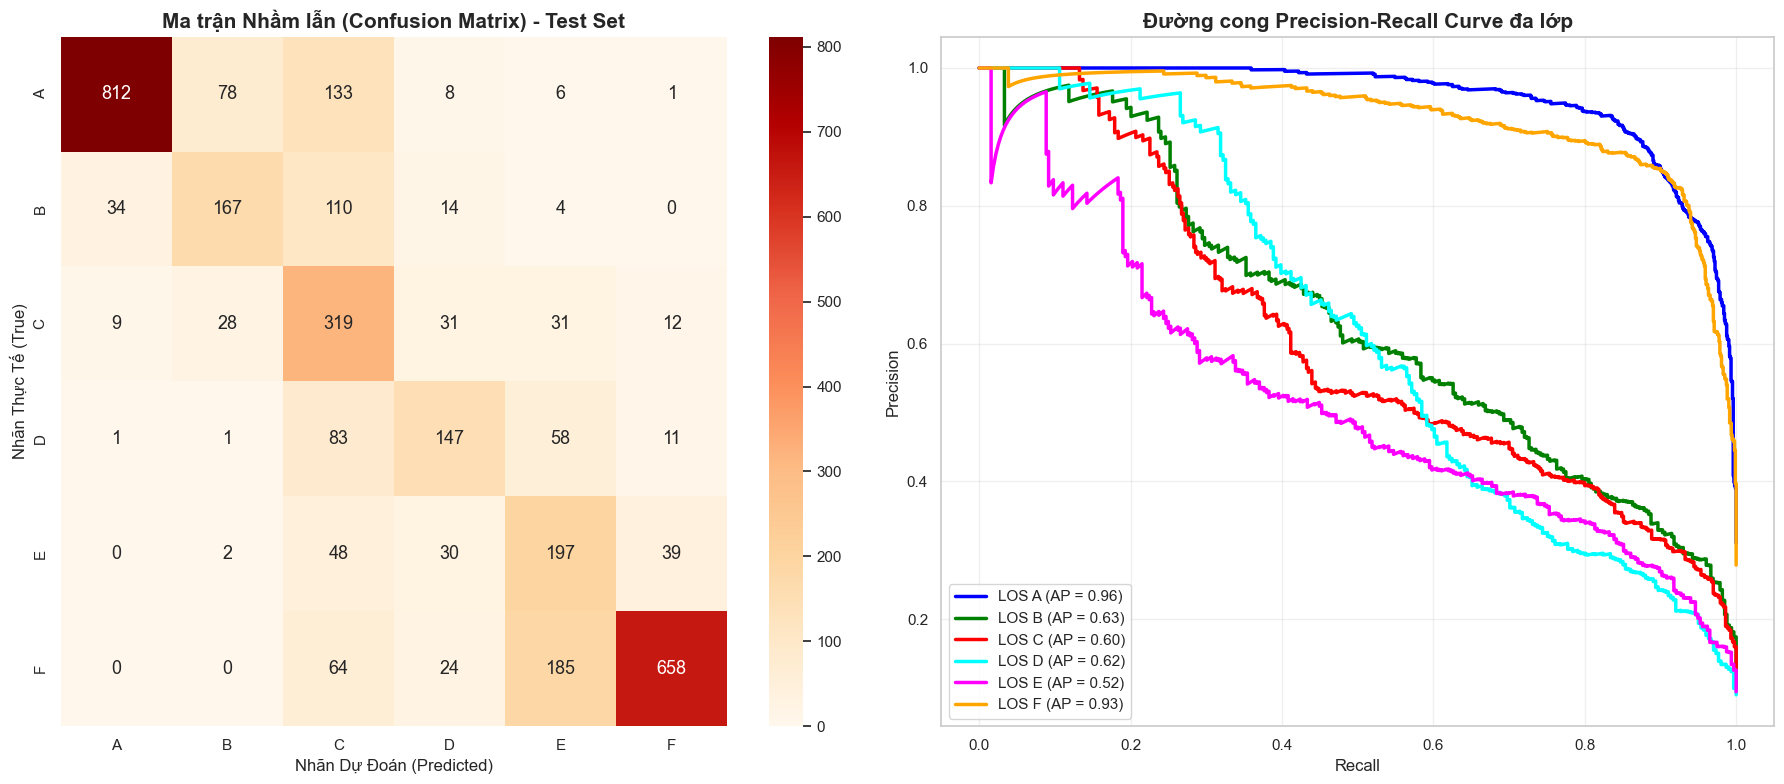

/var/folders/zz/bc9mj4q1537f2cyzn3nbmck00000gn/T/ipykernel_52528/2636464971.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=df_fi, palette='magma')


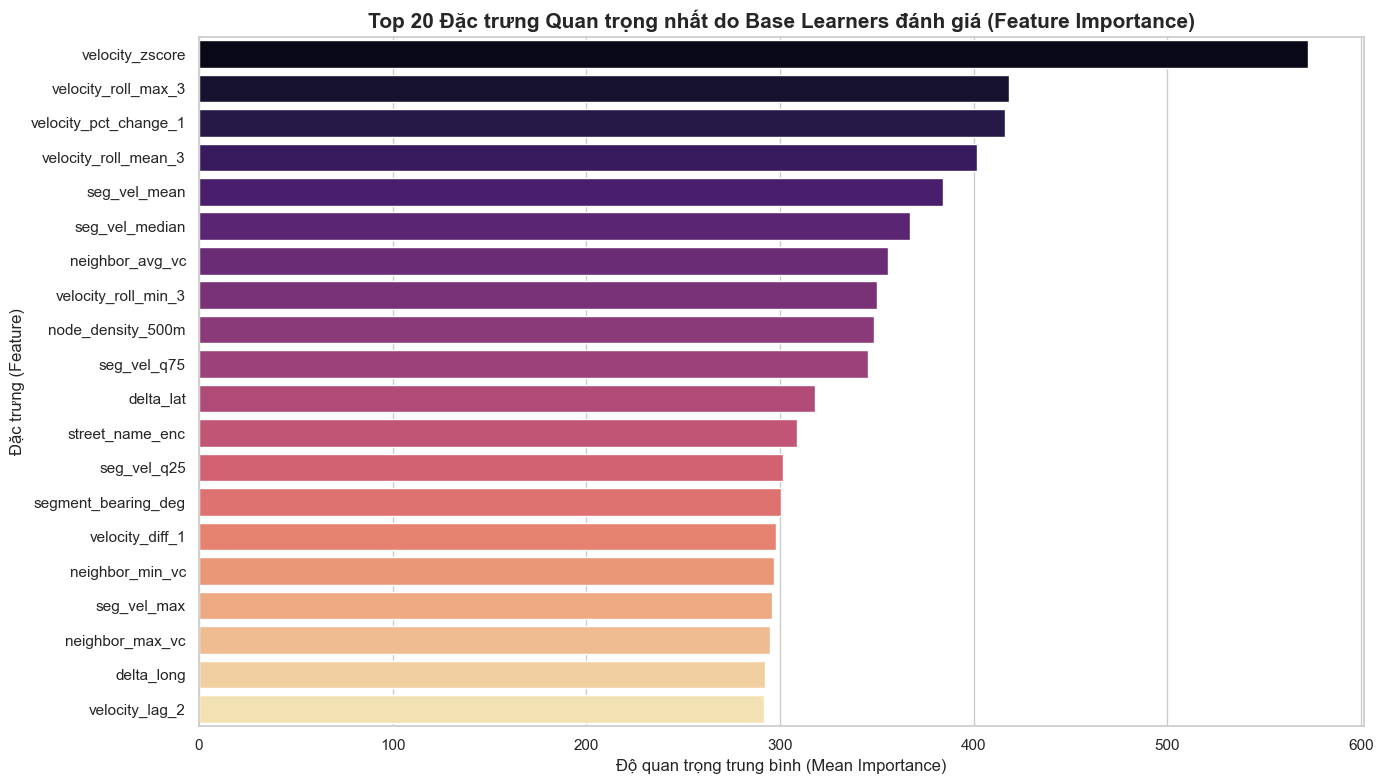

In [13]:
import joblib
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize

MODEL_PATH = Path('../models/stacking_ensemble_ITS.joblib')
TEST_PATH = Path('../scripts/data_after_split/test/test.csv')

if MODEL_PATH.exists() and TEST_PATH.exists():
    # 1. Load mô hình và dữ liệu Test
    print('Đang tải mô hình và tập Test Set...')
    pipeline = joblib.load(MODEL_PATH)
    test_df = pd.read_csv(TEST_PATH)
    
    feature_names_path = Path('../models/feature_names_used.json')
    with open(feature_names_path, 'r') as f:
        feature_names = json.load(f)['feature_names']
        
    X_test = test_df[feature_names]
    y_test_raw = test_df['LOS']
    
    # Tái tạo nhãn
    classes = ['A', 'B', 'C', 'D', 'E', 'F']
    y_test = y_test_raw.values
    
    # 2. Predict
    print('Đang dự đoán kết quả trên Test Set...')
    y_pred = pipeline.predict(X_test)
    try:
        y_probs = pipeline.predict_proba(X_test)
    except:
        y_probs = None
    
    print('\n================ CLASSIFICATION REPORT (TEST SET) ================')
    print(classification_report(y_test, y_pred, target_names=[f'LOS {c}' for c in classes]))
    
    # 3. Visualization CM & PR Curve
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    
    # Heatmap Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='OrRd', xticklabels=classes, yticklabels=classes, ax=axes[0], annot_kws={'size': 13})
    axes[0].set_title('Ma trận Nhầm lẫn (Confusion Matrix) - Test Set', fontsize=15, fontweight='bold')
    axes[0].set_ylabel('Nhãn Thực Tế (True)', fontsize=12)
    axes[0].set_xlabel('Nhãn Dự Đoán (Predicted)', fontsize=12)
    
    # Precision-Recall Curve
    if y_probs is not None:
        y_test_bin = label_binarize(y_test, classes=range(len(classes)))
        colors = ['blue', 'green', 'red', 'cyan', 'magenta', 'orange']
        for i in range(len(classes)):
            if i >= y_test_bin.shape[1]: break
            precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_probs[:, i])
            ap = average_precision_score(y_test_bin[:, i], y_probs[:, i])
            axes[1].plot(recall, precision, color=colors[i], lw=2.5, label=f'LOS {classes[i]} (AP = {ap:.2f})')
            
        axes[1].set_xlabel('Recall', fontsize=12)
        axes[1].set_ylabel('Precision', fontsize=12)
        axes[1].set_title('Đường cong Precision-Recall Curve đa lớp', fontsize=15, fontweight='bold')
        axes[1].legend(loc='lower left')
        axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # 4. Vẽ Feature Importance
    FI_PATH = Path('../models/feature_importance_mean.csv')
    if FI_PATH.exists():
        df_fi = pd.read_csv(FI_PATH).head(20)
        plt.figure(figsize=(14, 8))
        sns.barplot(x='importance', y='feature', data=df_fi, palette='magma')
        plt.title('Top 20 Đặc trưng Quan trọng nhất do Base Learners đánh giá (Feature Importance)', fontsize=15, fontweight='bold')
        plt.xlabel('Độ quan trọng trung bình (Mean Importance)', fontsize=12)
        plt.ylabel('Đặc trưng (Feature)', fontsize=12)
        plt.tight_layout()
        plt.show()
else:
    print('Không tìm thấy file mô hình hoặc tập test. Sếp vui lòng đảm bảo đã Train thành công!')


---
## 9. Khám phá Kết quả Dự báo Cuối cùng (Inference Results)
Sau khi mô hình được huấn luyện thành công, nó được triển khai để chạy dự báo thực tế thông qua file `prediction_ITS.py`.
Kết quả của hàng ngàn phân đoạn đường được xuất ra file `prediction_result.csv` với các cột giá trị chuyên sâu phục vụ cho Hệ thống Giao thông Thông minh (ITS).

### Ý nghĩa các trường dữ liệu đầu ra:
- **`segment_id`, `street_name`, `date`, `period`**: Định danh chính xác đoạn đường, tên đường và khung giờ được dự báo.
- **`LOS_pred`**: Nhãn dự đoán mức độ ùn tắc (từ A: Thông thoáng đến F: Tắc nghẽn nghiêm trọng).
- **`confidence_score`**: Độ tin cậy của dự đoán (từ 0.0 đến 1.0). Điểm càng gần 1.0 nghĩa là mô hình càng chắc chắn vào quyết định của mình.
- **`prob_LOS_A` đến `prob_LOS_F`**: Xác suất chi tiết cho từng nhãn. Giúp hệ thống ITS không chỉ biết kết quả mà còn lường trước rủi ro (Ví dụ: LOS là C nhưng xác suất D cũng rất cao => Cảnh báo sắp tắc đường).

In [14]:
PRED_PATH = Path('../scripts/outputs/prediction_result.csv')
if PRED_PATH.exists():
    df_pred = pd.read_csv(PRED_PATH)
    print(f'Đã nạp {len(df_pred):,} dòng kết quả dự đoán từ file prediction_result.csv!')
    # Hiển thị vài dòng mẫu ngẫu nhiên
    display(df_pred.sample(5, random_state=42))
else:
    print('Chưa có kết quả dự đoán. Sếp vui lòng chạy script prediction_ITS.py trước!')


Đã nạp 2,676 dòng kết quả dự đoán từ file prediction_result.csv!


,_id,segment_id,date,period,street_name,time_of_day_cat,LOS_pred,confidence_score,prob_LOS_A,prob_LOS_B,prob_LOS_C,prob_LOS_D,prob_LOS_E,prob_LOS_F
942,22577,55243,2020-12-26,period_11_00,Bạch Đằng,morning,A,0.9971,0.9971,0.0015,0.0007,0.0005,0.0001,0.0001
2358,15642,39072,2020-12-28,period_7_30,Cao Thắng,morning,A,0.9976,0.9976,0.0012,0.0006,0.0004,0.0001,0.0001
443,28878,65375,2020-12-24,period_3_00,Cách Mạng Tháng Tám,night,F,0.9968,0.0000,0.0000,0.0004,0.0007,0.0019,0.9968
1670,17873,44454,2020-12-26,period_9_30,Bùi Hữu Nghĩa,morning,A,0.9978,0.9978,0.0011,0.0005,0.0004,0.0001,0.0001
1977,14715,36808,2020-12-27,period_4_30,Trần Quốc Thảo,night,A,0.9976,0.9976,0.0012,0.0006,0.0004,0.0001,0.0001


/var/folders/zz/bc9mj4q1537f2cyzn3nbmck00000gn/T/ipykernel_52528/1666487570.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_pred, x='LOS_pred', order=['A', 'B', 'C', 'D', 'E', 'F'], palette='coolwarm', ax=axes[0])


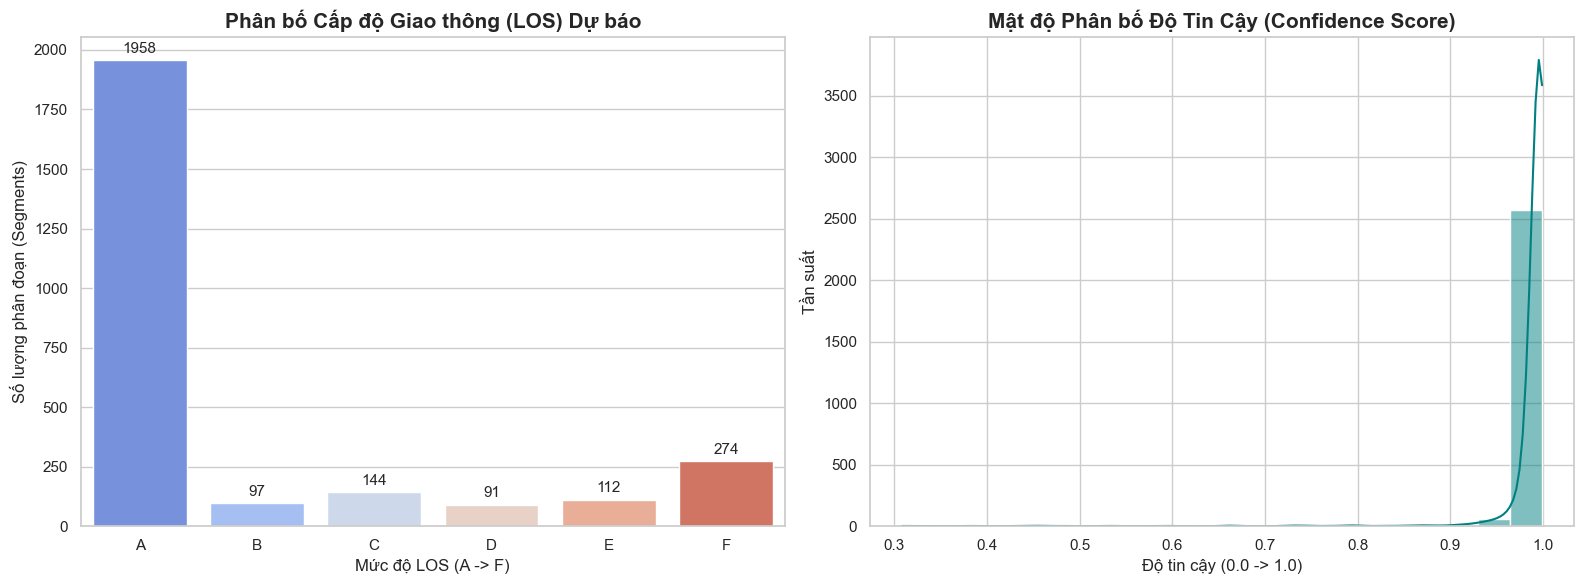

/var/folders/zz/bc9mj4q1537f2cyzn3nbmck00000gn/T/ipykernel_52528/1666487570.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['LOS A', 'LOS B', 'LOS C', 'LOS D', 'LOS E', 'LOS F'], y=probs, palette='viridis')


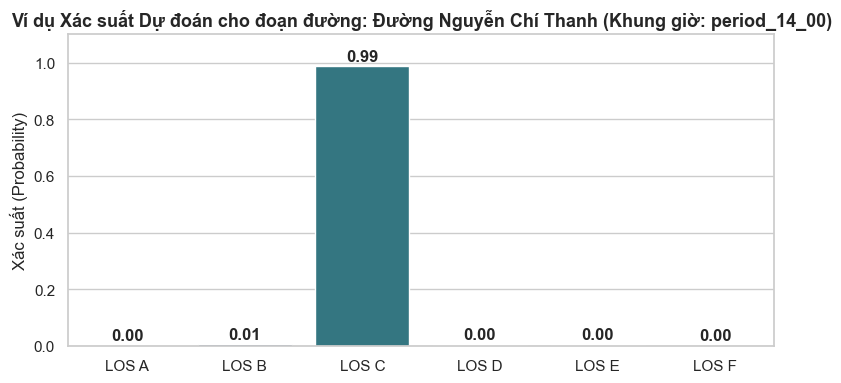

In [15]:
if PRED_PATH.exists():
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # 1. Phân bố Nhãn LOS dự đoán
    sns.countplot(data=df_pred, x='LOS_pred', order=['A', 'B', 'C', 'D', 'E', 'F'], palette='coolwarm', ax=axes[0])
    axes[0].set_title('Phân bố Cấp độ Giao thông (LOS) Dự báo', fontsize=15, fontweight='bold')
    axes[0].set_xlabel('Mức độ LOS (A -> F)', fontsize=12)
    axes[0].set_ylabel('Số lượng phân đoạn (Segments)', fontsize=12)
    
    for p in axes[0].patches:
        axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontsize=11)
    
    # 2. Phân bố Độ tin cậy (Confidence Score)
    sns.histplot(data=df_pred, x='confidence_score', bins=20, kde=True, color='teal', ax=axes[1])
    axes[1].set_title('Mật độ Phân bố Độ Tin Cậy (Confidence Score)', fontsize=15, fontweight='bold')
    axes[1].set_xlabel('Độ tin cậy (0.0 -> 1.0)', fontsize=12)
    axes[1].set_ylabel('Tần suất', fontsize=12)
    
    plt.tight_layout()
    plt.show()
    
    # 3. Phân tích Xác suất chi tiết của 1 mẫu bất kỳ
    sample = df_pred.iloc[0]
    probs = [sample[f'prob_LOS_{c}'] for c in ['A', 'B', 'C', 'D', 'E', 'F']]
    plt.figure(figsize=(8, 4))
    sns.barplot(x=['LOS A', 'LOS B', 'LOS C', 'LOS D', 'LOS E', 'LOS F'], y=probs, palette='viridis')
    plt.title(f"Ví dụ Xác suất Dự đoán cho đoạn đường: {sample['street_name']} (Khung giờ: {sample['period']})", fontsize=13, fontweight='bold')
    plt.ylabel('Xác suất (Probability)')
    plt.ylim(0, 1.1)
    for i, v in enumerate(probs):
        plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')
    plt.tight_layout()
    plt.show()
